In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1 = pd.read_excel(r"../india_weather_rainfall_data.xlsx")
df1

,date_of_record,month,season,station_name,state,district,avg_temp,min_temp,max_temp,wind_speed,air_pressure,elevation,latitude,longitude,rainfall
0,2021-01-02,January,Winter,Gulmarg,JK,Baramulla,-2.2,-6.6,-0.8,2.2,1020.0,2652,34.0500,74.4000,0.1
1,2021-01-03,January,Winter,Gulmarg,JK,Baramulla,-3.6,-4.6,-1.8,3.7,1019.5,2652,34.0500,74.4000,4.4
2,2021-01-04,January,Winter,Gulmarg,JK,Baramulla,-3.0,-4.5,-1.1,2.1,1022.0,2652,34.0500,74.4000,2.3
3,2021-01-05,January,Winter,Gulmarg,JK,Baramulla,-3.3,-5.1,-1.2,2.8,1015.6,2652,34.0500,74.4000,35.0
4,2021-01-06,January,Winter,Gulmarg,JK,Baramulla,-3.9,-8.3,-1.0,3.4,1015.3,2652,34.0500,74.4000,25.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
970334,2025-02-06,February,Winter,Vizagapatam / Gajuwaka,AP,Visakhapatnam,27.3,22.0,34.0,7.6,1011.4,5,17.7167,83.2333,0.0
970335,2025-02-07,February,Winter,Vizagapatam / Gajuwaka,AP,Visakhapatnam,26.7,23.0,30.0,7.7,1013.1,5,17.7167,83.2333,0.3
970336,2025-02-08,February,Winter,Vizagapatam / Gajuwaka,AP,Visakhapatnam,26.5,23.0,30.0,8.7,1013.0,5,17.7167,83.2333,0.0
970337,2025-02-09,February,Winter,Vizagapatam / Gajuwaka,AP,Visakhapatnam,26.5,23.0,30.0,8.5,1012.8,5,17.7167,83.2333,0.0


In [3]:
df1.columns

Index(['date_of_record', 'month', 'season', 'station_name', 'state',
       'district', 'avg_temp', 'min_temp', 'max_temp', 'wind_speed',
       'air_pressure', 'elevation', 'latitude', 'longitude', 'rainfall'],
      dtype='object')

In [4]:
numerical = df1.select_dtypes(include=['float64', 'int64']).columns
categorical = df1.select_dtypes(include=['object']).columns
time = df1.select_dtypes(include=['datetime64']).columns
print(numerical, categorical, time)

Index(['avg_temp', 'min_temp', 'max_temp', 'wind_speed', 'air_pressure',
       'elevation', 'latitude', 'longitude', 'rainfall'],
      dtype='object') Index(['month', 'season', 'station_name', 'state', 'district'], dtype='object') Index(['date_of_record'], dtype='object')


In [5]:
df1['max_temp'] = df1['max_temp'].fillna(df1.groupby(['month', 'station_name'])['max_temp'].transform('mean'))
df1['min_temp'] = df1['min_temp'].fillna(df1.groupby(['month', 'station_name'])['min_temp'].transform('mean'))
df1['wind_speed'] = df1['wind_speed'].fillna(df1.groupby(['month', 'station_name'])['wind_speed'].transform('mean'))
df1['air_pressure'] = df1['air_pressure'].fillna(df1.groupby(['month', 'station_name'])['air_pressure'].transform('mean'))
df1['rainfall'] = df1['rainfall'].fillna(df1.groupby(['month', 'station_name'])['rainfall'].transform('mean'))

In [6]:
df1.isna().sum()

date_of_record    0
month             0
season            0
station_name      0
state             0
district          0
avg_temp          0
min_temp          0
max_temp          0
wind_speed        0
air_pressure      0
elevation         0
latitude          0
longitude         0
rainfall          0
dtype: int64

In [7]:
df1.shape

(970339, 15)

In [9]:
df2 = df1.drop_duplicates()
df2.shape

(970339, 15)

In [11]:
df2['avg_temp_lag_1'] = df2.groupby(['state', 'district', 'month', 'season'])['avg_temp'].shift(1)
df2['avg_temp_lag_7'] = df2.groupby(['state', 'district', 'month', 'season'])['avg_temp'].shift(7)
df2.isna().sum()

date_of_record        0
month                 0
season                0
station_name          0
state                 0
district              0
avg_temp              0
min_temp              0
max_temp              0
wind_speed            0
air_pressure          0
elevation             0
latitude              0
longitude             0
rainfall              0
avg_temp_lag_1     3792
avg_temp_lag_7    26544
dtype: int64

In [12]:
df2['avg_temp_lag_1'] = df2['avg_temp_lag_1'].fillna(df2.groupby(['state', 'district', 'month', 'season'])['avg_temp_lag_1'].transform('mean'))
df2['avg_temp_lag_7'] = df2['avg_temp_lag_7'].fillna(df2.groupby(['state', 'district', 'month', 'season'])['avg_temp_lag_7'].transform('mean'))
df2.isnull().sum()

date_of_record    0
month             0
season            0
station_name      0
state             0
district          0
avg_temp          0
min_temp          0
max_temp          0
wind_speed        0
air_pressure      0
elevation         0
latitude          0
longitude         0
rainfall          0
avg_temp_lag_1    0
avg_temp_lag_7    0
dtype: int64

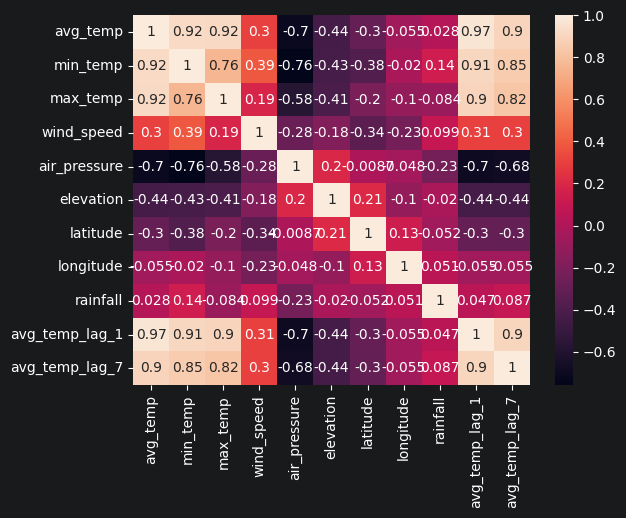

In [21]:
corr = df2.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

In [22]:
df2.columns

Index(['date_of_record', 'month', 'season', 'station_name', 'state',
       'district', 'avg_temp', 'min_temp', 'max_temp', 'wind_speed',
       'air_pressure', 'elevation', 'latitude', 'longitude', 'rainfall',
       'avg_temp_lag_1', 'avg_temp_lag_7'],
      dtype='object')

In [43]:
df3 = df2[['elevation', 'latitude', 'longitude',
       'avg_temp_lag_1', 'avg_temp_lag_7', 'avg_temp']]

In [63]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df3.iloc[:, :-1], df3.iloc[:, -1], test_size=0.2, random_state=42)

        elevation  latitude  longitude  avg_temp_lag_1  avg_temp_lag_7
602588        550   18.1500    74.5833            26.1            23.4
852097         85   10.7667    78.7167            30.7            29.0
459549        250   21.8167    75.6167            18.6            21.1
578373        261   19.9167    83.1833            22.2            20.1
396569        134   22.3000    70.7833            26.9            29.7
...           ...       ...        ...             ...             ...
151008        205   26.2333    78.2500            32.9            29.9
242681         88   25.3000    83.0167            29.4            26.5
839633         73   11.6667    92.7167            28.5            26.8
865193          1    9.9500    76.2667            27.3            24.9
277327        135   24.2000    72.2000            21.3            18.8

[194068 rows x 5 columns]


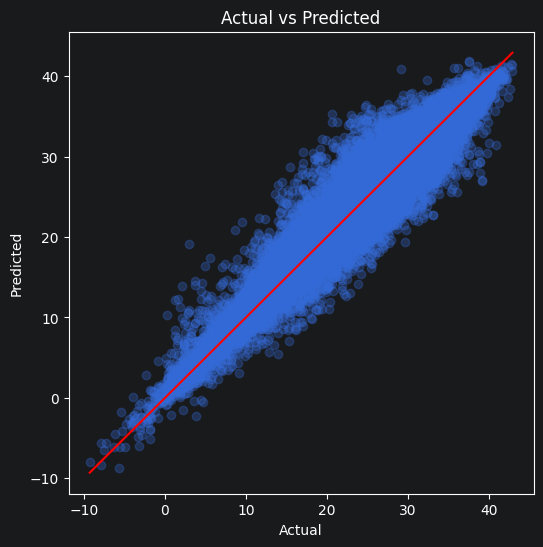

0.9462040084942838

In [64]:
from sklearn.linear_model import LinearRegression

print(x_test)

reg = LinearRegression()
reg.fit(x_train, y_train)
y_pred = reg.predict(x_test)
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.3)

# perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()
reg.score(x_test, y_test)

In [62]:
reg.predict(np.array([102, 23.23, 87.98, 32, 40]).reshape(1, -1))

/Users/sayangarai/Documents/Programming/Data Science/ml_env/mlenv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([32.65625689])